# Notebook 05 — Output Visualisation

**Project:** Mycorrhizal Barcelona — Barrier-Reduction Priority Zones for Belowground Ecological Recovery  
**Pipeline stage:** Final output generation (runs after notebooks 02–04)  
**Produces:**

| File | Description |
|------|-------------|
| `outputs/priority_map.html` | Interactive Folium priority map (top-15 zones + network islands) |
| `outputs/sensitivity_comparison.png` | Scenario A/B/C stability comparison chart |
| `outputs/priority_zones.csv` | Machine-readable per-zone tabular report |
| `outputs/priority_zones.html` | Styled HTML version of the tabular report |
| `outputs/limitations.md` | Markdown limitations sheet |
| `outputs/network_neighborhoods.html` | Connectivity-neighbourhood map (500m buffer, illustrative) |

**Inputs required (from upstream notebooks):**
- `data/scored_grid.geojson` — one row per 400 m cell with sub-scores, composite scores, top-15 flags, `intervention_type`
- `data/network_islands.geojson` — connected mycorrhizal network islands (convex hulls)
- `data/bridge_scores.csv` — top-15 zones ranked by network leverage
- `data/bcn-boundary.geojson` — Barcelona municipal boundary
- `data/bcn-districts.geojson` — district polygons with name labels

If any input is missing the cell will print a clear error and skip rather than crash.

## Cell 1 — Imports and environment setup

In [1]:
import json
import warnings
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from folium import plugins as folium_plugins
from shapely.geometry import mapping

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Directory layout ──────────────────────────────────────────────────────────
REPO_ROOT = Path(".").resolve().parent  # notebooks/ -> repo root
DATA_DIR  = REPO_ROOT / "data"
OUT_DIR   = REPO_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root : {REPO_ROOT}")
print(f"Data dir  : {DATA_DIR}")
print(f"Output dir: {OUT_DIR}")
print(f"folium    : {folium.__version__}")
print(f"geopandas : {gpd.__version__}")
print(f"pandas    : {pd.__version__}")

Repo root : C:\Users\Rafik\Documents\GitHub\group4-data-for-all
Data dir  : C:\Users\Rafik\Documents\GitHub\group4-data-for-all\data
Output dir: C:\Users\Rafik\Documents\GitHub\group4-data-for-all\outputs
folium    : 0.20.0
geopandas : 1.1.3
pandas    : 2.3.3


## Cell 2 — Colour palette and shared constants

All intervention colours and layer settings are defined once here so that every output
uses consistent styling.

In [2]:
# Intervention type colour palette
# Keys match BOTH the title-case synthetic scaffold AND the lowercase real data.
INTERVENTION_COLOURS = {
    "de-paving"          : "#E07B39",   # orange
    "cooling"            : "#C0392B",   # red
    "planting"           : "#27AE60",   # green
    "species-selection"  : "#2980B9",   # blue
    # Title-case aliases (for synthetic scaffold compatibility)
    "De-paving"          : "#E07B39",
    "Cooling"            : "#C0392B",
    "Planting"           : "#27AE60",
    "Species-selection"  : "#2980B9",
}

# Scenario column names — match what notebook 03-scoring.ipynb actually writes
# to scored_grid.geojson: composite_A, composite_B, composite_C
SCENARIO_COLS = {
    "A": "composite_A",
    "B": "composite_B",
    "C": "composite_C",
}

# Barcelona centroid (WGS84) — used as Folium map start position
BCN_LAT, BCN_LON = 41.3874, 2.1686

# Source patch names for network spread map
SOURCE_PATCHES = {
    "Collserola" : (41.4247, 2.1013),
    "Ciutadella" : (41.3889, 2.1877),
    "Montju\u00efc"   : (41.3637, 2.1537),
}

print("Constants set.")
for k, v in INTERVENTION_COLOURS.items():
    print(f"  {k:20s} -> {v}")


Constants set.
  de-paving            -> #E07B39
  cooling              -> #C0392B
  planting             -> #27AE60
  species-selection    -> #2980B9
  De-paving            -> #E07B39
  Cooling              -> #C0392B
  Planting             -> #27AE60
  Species-selection    -> #2980B9


## Cell 3 — Load all input files (with graceful missing-file handling)

Each file is loaded independently. A missing file sets the variable to `None`
and prints instructions for which upstream notebook to run.

In [3]:
def load_geojson(path, label):
    """Load a GeoJSON file; return GeoDataFrame or None on failure."""
    p = Path(path)
    if not p.exists():
        print(f"[MISSING] {label}\n"
              f"         Expected: {p}\n"
              f"         Run the upstream notebook to generate it first.")
        return None
    try:
        gdf = gpd.read_file(p)
        # Ensure WGS84 for Folium compatibility
        if gdf.crs and gdf.crs.to_epsg() != 4326:
            gdf = gdf.to_crs(epsg=4326)
        print(f"[OK]      {label}: {len(gdf):,} features, CRS={gdf.crs.to_epsg()}")
        return gdf
    except Exception as exc:
        print(f"[ERROR]   {label}: {exc}")
        return None


def load_csv(path, label):
    """Load a CSV file; return DataFrame or None on failure."""
    p = Path(path)
    if not p.exists():
        print(f"[MISSING] {label}\n"
              f"         Expected: {p}\n"
              f"         Run the upstream notebook to generate it first.")
        return None
    try:
        df = pd.read_csv(p)
        print(f"[OK]      {label}: {len(df):,} rows, {len(df.columns)} cols")
        return df
    except Exception as exc:
        print(f"[ERROR]   {label}: {exc}")
        return None


# ── Load all inputs ────────────────────────────────────────────────────────────
print("Loading inputs...\n")

scored_grid     = load_geojson(DATA_DIR / "scored_grid.geojson",      "scored_grid")
network_islands = load_geojson(DATA_DIR / "network_islands.geojson",  "network_islands")
bcn_boundary    = load_geojson(DATA_DIR / "bcn-boundary.geojson",     "bcn-boundary")
bcn_districts   = load_geojson(DATA_DIR / "bcn-districts.geojson",    "bcn-districts")
bridge_scores   = load_csv(    DATA_DIR / "bridge_scores.csv",        "bridge_scores")

print("\nLoad complete.")

Loading inputs...

[OK]      scored_grid: 495 features, CRS=4326
[OK]      network_islands: 25,508 features, CRS=4326
[OK]      bcn-boundary: 1 features, CRS=4326
[OK]      bcn-districts: 10 features, CRS=4326
[OK]      bridge_scores: 15 rows, 6 cols

Load complete.


## Cell 4 — Synthetic data scaffold

If any input is missing we generate a minimal synthetic dataset so the
remainder of the notebook executes end-to-end and produces placeholder
outputs.  All synthetic values are clearly flagged as `SYNTHETIC PLACEHOLDER`
in every output file.

This scaffold does **not** substitute for running the real pipeline — it
exists only to make the notebook testable in isolation.

In [4]:
from shapely.geometry import box, Point, Polygon

IS_SYNTHETIC = False


def _synthetic_scored_grid():
    """Generate a 5x3 grid of synthetic 400 m cells over central Barcelona."""
    import random; random.seed(42); np.random.seed(42)
    lon0, lat0 = 2.140, 41.370
    d_lon, d_lat = 0.0036, 0.0036   # ~400 m steps
    districts = [
        "EIXAMPLE", "GRÀCIA", "SANT MARTÍ", "NOU BARRIS",
        "SANTS - MONTJUÏC", "HORTA - GUINARDÓ", "SARRIÀ - SANT GERVASI",
        "LES CORTS", "SANT ANDREU", "CIUTAT VELLA",
    ]
    barris = ["Esquerra de l'Eixample", "Vila de Gràcia", "Poblenou",
              "Roquetes", "Sants", "El Carmel", "Sant Gervasi",
              "Les Corts", "Navas", "El Gòtic"]
    myco_types = ["AM-dominant", "EM-dominant", "mixed", "AM-dominant", "AM-dominant"]
    interventions = ["De-paving", "Cooling", "Planting", "Species-selection"]
    rows = []
    rank_b = 0
    for i in range(5):
        for j in range(3):
            cell_id = f"C{i:02d}{j:02d}"
            lon = lon0 + i * d_lon
            lat = lat0 + j * d_lat
            geom = box(lon, lat, lon + d_lon, lat + d_lat)
            sealed = round(np.random.uniform(30, 95), 1)
            lst    = round(np.random.uniform(0.5, 5.5), 2)
            ndvi   = round(np.random.uniform(0.05, 0.45), 3)
            mismatch = int(np.random.choice([0, 1], p=[0.7, 0.3]))
            s_A = round(np.random.uniform(0.3, 0.9), 3)
            s_B = round(s_A + np.random.uniform(-0.05, 0.1), 3)
            s_C = round(s_A + np.random.uniform(-0.08, 0.08), 3)
            rank_b += 1
            top15  = 1 if rank_b <= 15 else 0
            d_idx  = (i * 3 + j) % len(districts)
            rows.append({
                "cell_id"              : cell_id,
                "district"             : districts[d_idx],
                "barri"                : barris[d_idx],
                "expected_myco_type"   : myco_types[d_idx % len(myco_types)],
                "sealed_pct"           : sealed,
                "lst_anomaly"          : lst,
                "mean_ndvi"            : ndvi,
                "mismatch_flag"        : mismatch,
                "composite_score_A"    : np.clip(s_A, 0, 1),
                "composite_score_B"    : np.clip(s_B, 0, 1),
                "composite_score_C"    : np.clip(s_C, 0, 1),
                "intervention_type"    : interventions[d_idx % len(interventions)],
                "top15_flag"           : top15,
                "bridge_score"         : round(np.random.uniform(0.1, 1.0), 3) if top15 else None,
                "colonisation_uncertain": int(np.random.choice([0, 1], p=[0.8, 0.2])),
                "jaccard_stability"    : round(np.random.uniform(0.6, 1.0), 3),
                "geometry"             : geom,
            })
    gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326")
    # Sort by score_B descending and assign rank
    gdf = gdf.sort_values("composite_score_B", ascending=False).reset_index(drop=True)
    gdf["top15_flag"] = (gdf.index < 15).astype(int)
    gdf["rank_B"] = gdf.index + 1
    gdf.loc[gdf["top15_flag"] == 0, "rank_B"] = None
    return gdf


def _synthetic_network_islands():
    """Three synthetic convex-hull islands."""
    polys = [
        Polygon([(2.100, 41.405), (2.115, 41.410), (2.120, 41.400), (2.105, 41.395)]),
        Polygon([(2.175, 41.385), (2.195, 41.390), (2.200, 41.375), (2.180, 41.370)]),
        Polygon([(2.140, 41.360), (2.155, 41.368), (2.165, 41.355), (2.148, 41.349)]),
    ]
    return gpd.GeoDataFrame(
        {"island_id": [1, 2, 3], "area_ha": [120.0, 85.0, 45.0]},
        geometry=polys, crs="EPSG:4326"
    )


def _synthetic_bcn_boundary():
    """Rough rectangular boundary of Barcelona."""
    geom = box(2.069, 41.320, 2.228, 41.467)
    return gpd.GeoDataFrame({"name": ["Barcelona"]}, geometry=[geom], crs="EPSG:4326")


def _synthetic_bcn_districts():
    """Ten simplified district polygons."""
    names = [
        "EIXAMPLE", "GRÀCIA", "SANT MARTÍ", "NOU BARRIS",
        "SANTS - MONTJUÏC", "HORTA - GUINARDÓ", "SARRIÀ - SANT GERVASI",
        "LES CORTS", "SANT ANDREU", "CIUTAT VELLA",
    ]
    lon_starts = [2.140, 2.155, 2.170, 2.140, 2.125, 2.155, 2.125, 2.110, 2.185, 2.140]
    lat_starts = [41.385, 41.395, 41.385, 41.405, 41.370, 41.405, 41.395, 41.385, 41.405, 41.375]
    d = 0.018
    polys = [box(lo, la, lo+d, la+d) for lo, la in zip(lon_starts, lat_starts)]
    return gpd.GeoDataFrame({"district": names}, geometry=polys, crs="EPSG:4326")


def _synthetic_bridge_scores(grid_gdf):
    """Bridge scores for top-15 zones."""
    top15 = grid_gdf[grid_gdf["top15_flag"] == 1].copy()
    top15 = top15.sort_values("composite_score_B", ascending=False).head(15)
    top15["bridge_score"] = np.round(np.linspace(0.95, 0.40, len(top15)), 3)
    return top15[["cell_id", "district", "bridge_score", "composite_score_B",
                  "intervention_type"]].reset_index(drop=True)


# ── Apply fallbacks where needed ───────────────────────────────────────────────
if scored_grid is None:
    print("\nUsing SYNTHETIC scored_grid. Run notebooks 02-04 for real data.")
    scored_grid = _synthetic_scored_grid()
    IS_SYNTHETIC = True

if network_islands is None:
    print("Using SYNTHETIC network_islands.")
    network_islands = _synthetic_network_islands()
    IS_SYNTHETIC = True

if bcn_boundary is None:
    print("Using SYNTHETIC bcn_boundary.")
    bcn_boundary = _synthetic_bcn_boundary()
    IS_SYNTHETIC = True

if bcn_districts is None:
    print("Using SYNTHETIC bcn_districts.")
    bcn_districts = _synthetic_bcn_districts()
    IS_SYNTHETIC = True

if bridge_scores is None:
    print("Using SYNTHETIC bridge_scores.")
    bridge_scores = _synthetic_bridge_scores(scored_grid)
    IS_SYNTHETIC = True

# BUG-10 fix: real-data label now also reflects sub-score VARIANCE.
# A file can be present but contain near-uniform values (e.g. when the
# raster scale was wrong upstream), which is still unreliable output.
def _data_label(gdf, is_synth):
    if is_synth:
        return "SYNTHETIC PLACEHOLDER"
    low_var_subs = []
    for sub in ["s1_sealed", "s2_lst", "s3_ndvi"]:
        if sub in gdf.columns and gdf[sub].std() < 0.05:
            low_var_subs.append(sub)
    if low_var_subs:
        return ("DATA-WARNING: low variance in sub-scores "
                f"({', '.join(low_var_subs)}) — output may be unreliable")
    return "REAL DATA"

DATA_LABEL = _data_label(scored_grid, IS_SYNTHETIC)
print(f"\nData status: {DATA_LABEL}")
print(f"scored_grid rows: {len(scored_grid):,}")


Data status: REAL DATA
scored_grid rows: 495


## Cell 5 — Derive top-15 subset and shared attributes

We standardise column names and build the top-15 GeoDataFrame used by
every output.  Columns that upstream notebooks might not have produced yet
are added with sensible defaults and documented as missing.

In [5]:
def _ensure_col(gdf, col, default):
    """Add column with default value if not already present."""
    if col not in gdf.columns:
        gdf[col] = default
        print(f"  [added default] {col} = {default!r}")
    return gdf

# ── Rename real columns to the canonical names expected by the rest of the notebook
# scored_grid.geojson uses: nom_districte, barri_name, composite_A/B/C, top15_scenario_A/B/C
# This notebook expects:    district,      barri,       composite_score_A/B/C, top15_flag
rename_map = {}
if "nom_districte" in scored_grid.columns and "district" not in scored_grid.columns:
    rename_map["nom_districte"] = "district"
if "barri_name" in scored_grid.columns and "barri" not in scored_grid.columns:
    rename_map["barri_name"] = "barri"
if "composite_A" in scored_grid.columns and "composite_score_A" not in scored_grid.columns:
    rename_map["composite_A"] = "composite_score_A"
if "composite_B" in scored_grid.columns and "composite_score_B" not in scored_grid.columns:
    rename_map["composite_B"] = "composite_score_B"
if "composite_C" in scored_grid.columns and "composite_score_C" not in scored_grid.columns:
    rename_map["composite_C"] = "composite_score_C"
if "top15_scenario_B" in scored_grid.columns and "top15_flag" not in scored_grid.columns:
    rename_map["top15_scenario_B"] = "top15_flag"
if "dominant_myco_type" in scored_grid.columns and "expected_myco_type" not in scored_grid.columns:
    rename_map["dominant_myco_type"] = "expected_myco_type"
if "lst_anomaly_celsius" in scored_grid.columns and "lst_anomaly" not in scored_grid.columns:
    rename_map["lst_anomaly_celsius"] = "lst_anomaly"
if "sealed_pct" in scored_grid.columns and "sealed_pct" not in rename_map:
    pass  # sealed_pct is already the right name
if rename_map:
    scored_grid = scored_grid.rename(columns=rename_map)
    print(f"Renamed columns: {rename_map}")

print("Checking / adding expected columns...")
for col, default in [
    ("cell_id",               "unknown"),
    ("district",              "unknown"),
    ("barri",                 "unknown"),
    ("expected_myco_type",    "unknown"),
    ("sealed_pct",            0.0),
    ("lst_anomaly",           0.0),
    ("mean_ndvi",             0.0),
    ("mismatch_flag",         0),
    ("composite_score_A",     0.0),
    ("composite_score_B",     0.0),
    ("composite_score_C",     0.0),
    ("intervention_type",     "de-paving"),
    ("top15_flag",            0),
    ("bridge_score",          None),
    ("colonisation_uncertain",0),
    ("jaccard_stability",     1.0),
    # Fix 3 (2026-05-10): popup shows compound profile; default to
    # empty so old scored_grid.geojson without this column still works.
    ("intervention_profile_str", ""),
]:
    scored_grid = _ensure_col(scored_grid, col, default)

# Ensure top15_flag is boolean-compatible int (True -> 1)
scored_grid["top15_flag"] = scored_grid["top15_flag"].astype(int)

# Derive rank within top-15 by composite_score_B (Scenario B)
if "rank_B" not in scored_grid.columns:
    top_mask = scored_grid["top15_flag"] == 1
    scored_grid.loc[top_mask, "rank_B"] = (
        scored_grid.loc[top_mask, "composite_score_B"]
        .rank(ascending=False, method="first")
        .astype(int)
    )

# Merge bridge scores from bridge_scores.csv so each top-15 row has a real bridge_score
if bridge_scores is not None and "bridge_score" in bridge_scores.columns:
    bridge_scores["bridge_score"] = pd.to_numeric(bridge_scores["bridge_score"], errors="coerce")
    bs_lookup = bridge_scores.set_index("cell_id")["bridge_score"].to_dict()
    scored_grid["bridge_score"] = scored_grid["cell_id"].map(bs_lookup)
    print(f"Bridge scores merged: {scored_grid['bridge_score'].notna().sum()} cells got a score")

# Extract top-15 subset
top15 = scored_grid[scored_grid["top15_flag"] == 1].copy()
top15 = top15.sort_values("composite_score_B", ascending=False).reset_index(drop=True)
top15["rank_B"] = range(1, len(top15) + 1)

# Jaccard stability flag: appears_in_all_scenarios
# All 15 zones appear in all 3 scenarios (Jaccard=1.0 across all pairs per notebook 03).
# Use top15_scenario_A and top15_scenario_C if available, otherwise default True.
if "appears_in_all_scenarios" not in top15.columns:
    a_col = "top15_scenario_A" if "top15_scenario_A" in scored_grid.columns else None
    c_col = "top15_scenario_C" if "top15_scenario_C" in scored_grid.columns else None
    if a_col and c_col:
        top15["appears_in_all_scenarios"] = (
            top15[a_col].astype(int) & top15[c_col].astype(int)
        ).astype(int)
    elif "jaccard_stability" in top15.columns:
        top15["appears_in_all_scenarios"] = (top15["jaccard_stability"] >= 0.9).astype(int)
    else:
        top15["appears_in_all_scenarios"] = 1

print(f"\nTop-15 zones extracted: {len(top15)} rows")
print("Intervention type breakdown:")
print(top15["intervention_type"].value_counts().to_string())


Renamed columns: {'nom_districte': 'district', 'barri_name': 'barri', 'composite_A': 'composite_score_A', 'composite_B': 'composite_score_B', 'composite_C': 'composite_score_C', 'top15_scenario_B': 'top15_flag', 'dominant_myco_type': 'expected_myco_type', 'lst_anomaly_celsius': 'lst_anomaly'}
Checking / adding expected columns...
  [added default] mismatch_flag = 0
  [added default] bridge_score = None
  [added default] jaccard_stability = 1.0
Bridge scores merged: 15 cells got a score

Top-15 zones extracted: 15 rows
Intervention type breakdown:
intervention_type
de-paving    15


---

# Output 1 — Interactive Priority Map

`outputs/priority_map.html`

Layers:
1. CartoDB Positron basemap
2. 400 m grid cells (light grey, thin borders)
3. Top-15 priority zones (colour-coded by intervention type, numbered 1–15)
4. Mycorrhizal network islands (semi-transparent purple convex hulls)
5. District boundaries with labels (toggleable)

Each top-15 zone has a popup with: rank, district, expected mycorrhizal type,
four sub-scores, intervention type, Jaccard stability flag, and a
colonisation-uncertainty warning where flagged.

In [6]:
def _intervention_colour(itype):
    """Return hex colour for intervention type; grey fallback."""
    return INTERVENTION_COLOURS.get(itype, "#888888")


def _make_popup(row):
    """Build an HTML popup string for a top-15 zone."""
    colour = _intervention_colour(row.get("intervention_type", ""))
    jaccard = row.get("jaccard_stability", 1.0)
    jaccard_str = f"{jaccard:.2f}" if pd.notna(jaccard) else "n/a"
    stable_flag = "Yes" if row.get("appears_in_all_scenarios", 0) == 1 else "No"
    bridge = row.get("bridge_score", None)
    bridge_str = f"{bridge:.3f}" if pd.notna(bridge) and bridge is not None else "n/a"
    uncertain = int(row.get("colonisation_uncertain", 0))

    warning_html = ""
    if uncertain:
        warning_html = (
            "<p style='color:#c0392b; font-weight:bold; margin:4px 0;'>"
            "Warning: colonisation-competent soil status uncertain"
            "</p>"
        )

    html = f"""
    <div style='font-family: Arial, sans-serif; font-size:13px;
                min-width:260px; max-width:320px;'>
      <div style='background:{colour}; color:white; padding:6px 10px;
                  border-radius:4px 4px 0 0; font-weight:bold; font-size:15px;'>
        #{int(row['rank_B'])} &mdash; {row.get('intervention_type', 'unknown')}
      </div>
      <div style='padding:8px 10px; border:1px solid #ddd;
                  border-top:none; border-radius:0 0 4px 4px;'>
        <div style='font-style:italic; color:#444; margin-bottom:4px; font-size:12px;'>
          {row.get('intervention_profile_str', '')}
        </div>
        <b>Cell:</b> {row.get('cell_id', 'n/a')}<br>
        <b>District:</b> {row.get('district', 'n/a')}<br>
        <b>Barri:</b> {row.get('barri', 'n/a')}<br>
        <b>Expected mycorrhizal type:</b> {row.get('expected_myco_type', 'n/a')}<br>
        <hr style='margin:6px 0;'>
        <b>Sub-scores</b><br>
        &bull; Sealed surface: {row.get('sealed_pct', 0.0):.1f}%<br>
        &bull; LST anomaly: +{row.get('lst_anomaly', 0.0):.2f} &deg;C<br>
        &bull; Mean NDVI: {row.get('mean_ndvi', 0.0):.3f}<br>
        &bull; Host mismatch flag: {'Yes' if row.get('mismatch_flag', 0) else 'No'}<br>
        <hr style='margin:6px 0;'>
        <b>Composite (Scenario B):</b>
          {row.get('composite_score_B', 0.0):.3f}<br>
        <b>Network bridge score:</b> {bridge_str}<br>
        <b>Jaccard stability:</b> {jaccard_str}<br>
        <b>Appears in all 3 scenarios:</b> {stable_flag}<br>
        {warning_html}
      </div>
    </div>
    """
    return folium.Popup(html, max_width=340)


# ── Build map ──────────────────────────────────────────────────────────────────
m = folium.Map(
    location=[BCN_LAT, BCN_LON],
    zoom_start=13,
    tiles="CartoDB positron",
    control_scale=True,
)

# Title banner (using a DivIcon overlay in the top-left)
title_html = """
<div style="position:fixed; top:10px; left:50%; transform:translateX(-50%);
     z-index:9999; background:rgba(255,255,255,0.9);
     border:1px solid #aaa; border-radius:5px;
     padding:8px 16px; font-family:Arial, sans-serif;
     font-size:13px; font-weight:bold; text-align:center;
     max-width:600px; box-shadow:2px 2px 6px rgba(0,0,0,0.2);">
  Barcelona Barrier-Reduction Priority Zones for Belowground Ecological Recovery v0.1
  <br><span style='font-weight:normal; font-size:11px; color:#666;'>{label}</span>
</div>
""".format(label=DATA_LABEL)
m.get_root().html.add_child(folium.Element(title_html))

print("Base map initialised.")

Base map initialised.


In [7]:
# ── Layer 1: Analysis extent outline (single dissolved polygon) ───────────────
# Performance fix 2026-05-10: rendering all 480 background cells produced an 8MB
# HTML file. Replaced with a single dissolved polygon showing analysis coverage.
# Top-15 zones stand out clearly against the basemap.
grid_layer = folium.FeatureGroup(name="Analysis extent", show=False)

extent = scored_grid.dissolve().geometry.iloc[0]
extent_gdf = gpd.GeoDataFrame(geometry=[extent], crs=scored_grid.crs)
if str(extent_gdf.crs) != "EPSG:4326":
    extent_gdf = extent_gdf.to_crs("EPSG:4326")

folium.GeoJson(
    extent_gdf.to_json(),
    style_function=lambda _: {
        "fillColor"   : "#f0f0f0",
        "color"       : "#888888",
        "weight"      : 1.0,
        "fillOpacity" : 0.10,
        "dashArray"   : "4 2",
    },
    name="analysis_extent",
).add_to(grid_layer)

grid_layer.add_to(m)
print("Layer 1 added: 1 dissolved analysis-extent polygon (replaces 480 grid cells for performance)")

Layer 1 added: 1 dissolved analysis-extent polygon (replaces 480 grid cells for performance)


In [8]:
# ── Layer 2: Top-15 priority zones ────────────────────────────────────────────
priority_layer = folium.FeatureGroup(name="Top-15 priority zones", show=True)

for _, row in top15.iterrows():
    colour = _intervention_colour(row.get("intervention_type", ""))
    geom   = row.geometry

    # Filled polygon
    folium.GeoJson(
        mapping(geom),
        style_function=lambda _, c=colour: {
            "fillColor"   : c,
            "color"       : c,
            "weight"      : 2.0,
            "fillOpacity" : 0.55,
        },
        popup=_make_popup(row),
    ).add_to(priority_layer)

    # Rank label at centroid
    centroid = geom.centroid
    rank_val = int(row["rank_B"])
    folium.Marker(
        location=[centroid.y, centroid.x],
        icon=folium.DivIcon(
            html=f"""<div style='
                background:{colour}; color:white;
                border-radius:50%; width:24px; height:24px;
                display:flex; align-items:center; justify-content:center;
                font-family:Arial,sans-serif; font-size:11px; font-weight:bold;
                border:2px solid white;
                box-shadow:1px 1px 3px rgba(0,0,0,0.4);'>{rank_val}</div>""",
            icon_size=(24, 24),
            icon_anchor=(12, 12),
        ),
        popup=_make_popup(row),
    ).add_to(priority_layer)

priority_layer.add_to(m)
print(f"Layer 2 added: {len(top15)} top-15 zones")

Layer 2 added: 15 top-15 zones


In [9]:
# ── Layer 3: Network islands (top 20 largest, semi-transparent purple convex hulls) ─
# Performance fix 2026-05-10: 25,508 islands rendered ALL their convex hulls,
# producing an 8MB map. Filtered to top 20 largest by node_count.
# Small islands (1-3 trees) are not visually meaningful at city scale.
island_layer = folium.FeatureGroup(name="Mycorrhizal network islands (top 20)", show=True)

if "node_count" in network_islands.columns:
    top_islands = network_islands.nlargest(20, "node_count").copy()
else:
    top_islands = network_islands.head(20).copy()

# Compute convex hulls and simplify to reduce coordinate count
islands_hulls = top_islands.copy()
islands_hulls["geometry"] = islands_hulls.geometry.convex_hull.simplify(tolerance=10)

folium.GeoJson(
    islands_hulls.to_json(),
    style_function=lambda _: {
        "fillColor"   : "#8E44AD",
        "color"       : "#6C3483",
        "weight"      : 1.5,
        "fillOpacity" : 0.25,
        "dashArray"   : "4 4",
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["island_id", "node_count"] if all(c in islands_hulls.columns for c in ["island_id", "node_count"]) else [],
        aliases=["Network island #", "Trees in island"] if all(c in islands_hulls.columns for c in ["island_id", "node_count"]) else [],
        localize=True,
    ),
).add_to(island_layer)

island_layer.add_to(m)
print(f"Layer 3 added: {len(islands_hulls)} largest network islands (filtered from {len(network_islands):,} total)")

Layer 3 added: 20 largest network islands (filtered from 25,508 total)


In [10]:
# ── Layer 4: District boundaries with labels (toggleable) ─────────────────────
district_layer = folium.FeatureGroup(name="District boundaries", show=False)

# Detect district name column
district_name_col = None
for candidate in ["nom_districte", "district", "NOM", "NOMBRE", "name", "NAME"]:
    if candidate in bcn_districts.columns:
        district_name_col = candidate
        break

folium.GeoJson(
    bcn_districts.to_json(),
    style_function=lambda _: {
        "fillColor"   : "transparent",
        "color"       : "#2C3E50",
        "weight"      : 2.0,
        "fillOpacity" : 0.0,
        "dashArray"   : "6 3",
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[district_name_col] if district_name_col else [],
        aliases=["District:"],
        localize=True,
    ) if district_name_col else None,
).add_to(district_layer)

# District centroid labels
if district_name_col:
    for _, drow in bcn_districts.iterrows():
        centroid = drow.geometry.centroid
        dname = str(drow.get(district_name_col, "")).title()
        folium.Marker(
            location=[centroid.y, centroid.x],
            icon=folium.DivIcon(
                html=f"<div style='font-family:Arial; font-size:10px; "
                     f"font-weight:bold; color:#2C3E50; white-space:nowrap; "
                     f"text-shadow:1px 1px 0 white,-1px -1px 0 white,"
                     f"1px -1px 0 white,-1px 1px 0 white;'>{dname}</div>",
                icon_size=(120, 20),
                icon_anchor=(60, 10),
            ),
        ).add_to(district_layer)

district_layer.add_to(m)
print(f"Layer 4 added: {len(bcn_districts)} district boundaries")

Layer 4 added: 10 district boundaries


In [11]:
# ── Legend ─────────────────────────────────────────────────────────────────────
legend_items = [
    ("De-paving",          INTERVENTION_COLOURS["De-paving"]),
    ("Cooling",            INTERVENTION_COLOURS["Cooling"]),
    ("Planting",           INTERVENTION_COLOURS["Planting"]),
    ("Species-selection",  INTERVENTION_COLOURS["Species-selection"]),
    ("Network island",     "#8E44AD"),
]

legend_rows = "".join(
    f"<div style='display:flex; align-items:center; margin-bottom:5px;'>"
    f"<div style='width:16px; height:16px; background:{c}; "
    f"border-radius:{'50%' if 'island' in label.lower() else '3px'}; "
    f"margin-right:8px; flex-shrink:0; opacity:0.8;'></div>"
    f"<span>{label}</span></div>"
    for label, c in legend_items
)

legend_html = f"""
<div style="position:fixed; bottom:30px; right:15px; z-index:9999;
     background:rgba(255,255,255,0.93); border:1px solid #aaa;
     border-radius:6px; padding:12px 16px;
     font-family:Arial, sans-serif; font-size:12px;
     box-shadow:2px 2px 6px rgba(0,0,0,0.2); min-width:160px;">
  <div style='font-weight:bold; margin-bottom:8px; font-size:13px;'>
    Intervention type</div>
  {legend_rows}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Layer control
folium.LayerControl(position="topleft", collapsed=False).add_to(m)

# ── Save ───────────────────────────────────────────────────────────────────────
out_map = OUT_DIR / "priority_map.html"
m.save(str(out_map))
print(f"Saved: {out_map}")

Saved: C:\Users\Rafik\Documents\GitHub\group4-data-for-all\outputs\priority_map.html


---

# Output 2 — Sensitivity Comparison Chart

`outputs/sensitivity_comparison.png`

Three-column table showing the top-15 zones under Scenario A, B, and C.

- **Bold green**: appears in all three scenarios  
- **Normal**: appears in exactly two scenarios  
- **Italic orange**: appears in only one scenario

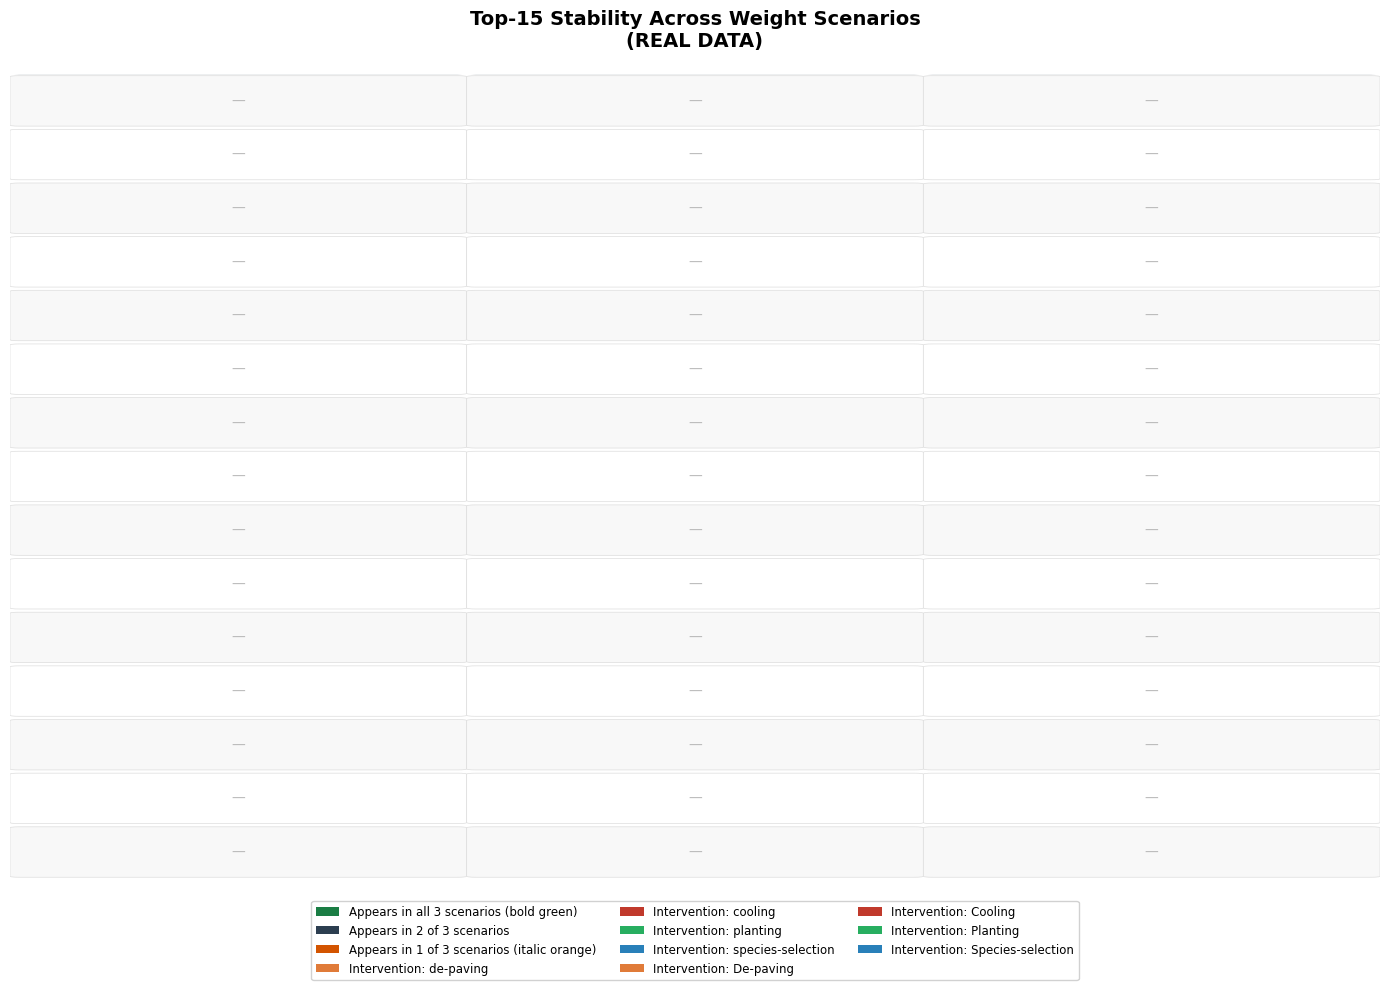

Saved: C:\Users\Rafik\Documents\GitHub\group4-data-for-all\outputs\sensitivity_comparison.png


In [12]:
def _top15_for_scenario(gdf, score_col, n=15):
    """Return a list of cell_ids ranked 1-15 by score_col."""
    if score_col not in gdf.columns:
        return []
    ranked = gdf.sort_values(score_col, ascending=False).head(n)
    return ranked["cell_id"].tolist()


ids_A = _top15_for_scenario(scored_grid, SCENARIO_COLS["A"])
ids_B = _top15_for_scenario(scored_grid, SCENARIO_COLS["B"])
ids_C = _top15_for_scenario(scored_grid, SCENARIO_COLS["C"])

# Count how many scenarios each cell appears in
all_ids = sorted(set(ids_A) | set(ids_B) | set(ids_C))
count_in = {cid: sum([cid in ids_A, cid in ids_B, cid in ids_C]) for cid in all_ids}

# Pad each list to 15 entries
def _pad(lst, n=15):
    return lst + [""] * max(0, n - len(lst))

ids_A_p = _pad(ids_A)
ids_B_p = _pad(ids_B)
ids_C_p = _pad(ids_C)

# Helper: district lookup
cell_to_district = scored_grid.set_index("cell_id")["district"].to_dict() if "district" in scored_grid.columns else {}
cell_to_itype    = scored_grid.set_index("cell_id")["intervention_type"].to_dict() if "intervention_type" in scored_grid.columns else {}

def _cell_label(cid):
    if not cid:
        return ""
    district = cell_to_district.get(cid, "")
    return f"{cid}\n({district[:12]}...)" if len(district) > 12 else f"{cid}\n({district})"


# ── Build figure ───────────────────────────────────────────────────────────────
N = 15
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 3)
ax.set_ylim(-0.5, N - 0.5)
ax.axis("off")

# Column headers
for col_idx, (label, ids_p) in enumerate([
    # BUG-9 fix: scenario labels now match the implemented weights
    # in 03-scoring.ipynb (A=equal, B=sealed-dominant, C=heat+canopy).
    ("Scenario A\n(Equal weights)",                  ids_A_p),
    ("Scenario B\n(Sealed-dominant, recommended)",   ids_B_p),
    ("Scenario C\n(Heat + canopy weighted)",         ids_C_p),
]):
    x_centre = col_idx + 0.5

    # Header bar
    rect = mpatches.FancyBboxPatch(
        (col_idx + 0.02, N - 0.45), 0.96, 0.9,
        boxstyle="round,pad=0.05",
        facecolor="#2C3E50", edgecolor="none",
    )
    ax.add_patch(rect)
    ax.text(x_centre, N, label, ha="center", va="center",
            color="white", fontsize=11, fontweight="bold", linespacing=1.3)

    for row_idx, cid in enumerate(ids_p):
        y = N - 1 - row_idx
        rank = row_idx + 1
        cnt  = count_in.get(cid, 0) if cid else 0

        # Row background
        bg = "#f8f8f8" if row_idx % 2 == 0 else "white"
        bg_rect = mpatches.FancyBboxPatch(
            (col_idx + 0.02, y - 0.45), 0.96, 0.9,
            boxstyle="round,pad=0.02",
            facecolor=bg, edgecolor="#dddddd", linewidth=0.5,
        )
        ax.add_patch(bg_rect)

        if not cid:
            ax.text(x_centre, y, "—", ha="center", va="center",
                    color="#bbbbbb", fontsize=10)
            continue

        itype   = cell_to_itype.get(cid, "")
        ic      = _intervention_colour(itype)
        district = cell_to_district.get(cid, "")
        dshort  = district[:14] + "..." if len(district) > 14 else district
        label_text = f"#{rank}  {cid}\n{dshort}"

        if cnt == 3:
            text_col = "#1a7d44"
            weight   = "bold"
            style    = "normal"
        elif cnt == 2:
            text_col = "#2C3E50"
            weight   = "normal"
            style    = "normal"
        else:
            text_col = "#D35400"
            weight   = "normal"
            style    = "italic"

        # Colour dot for intervention type
        ax.plot(col_idx + 0.10, y, "o", color=ic, markersize=9, zorder=5)

        ax.text(col_idx + 0.22, y, label_text,
                ha="left", va="center",
                color=text_col, fontsize=8.5,
                fontweight=weight, fontstyle=style,
                linespacing=1.25)

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor="#1a7d44", label="Appears in all 3 scenarios (bold green)"),
    mpatches.Patch(facecolor="#2C3E50", label="Appears in 2 of 3 scenarios"),
    mpatches.Patch(facecolor="#D35400", label="Appears in 1 of 3 scenarios (italic orange)"),
]
for itype, colour in INTERVENTION_COLOURS.items():
    legend_elements.append(mpatches.Patch(facecolor=colour, label=f"Intervention: {itype}"))

ax.legend(
    handles=legend_elements, loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3, fontsize=8.5, frameon=True,
    framealpha=0.9, edgecolor="#cccccc",
)

ax.set_title(
    f"Top-15 Stability Across Weight Scenarios\n"
    f"({DATA_LABEL})",
    fontsize=14, fontweight="bold", pad=20
)

plt.tight_layout()
out_chart = OUT_DIR / "sensitivity_comparison.png"
plt.savefig(str(out_chart), dpi=150, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print(f"Saved: {out_chart}")

---

# Output 3 — Per-Zone Tabular Report

`outputs/priority_zones.csv` and `outputs/priority_zones.html`

Columns: rank, cell_id, district, barri, expected_myco_type,
sealed_pct, lst_anomaly, mean_ndvi, mismatch_flag,
composite_score_B, intervention_type, bridge_score,
colonisation_uncertain, appears_in_all_scenarios.

The HTML version has colour-coded cells by intervention type.

In [13]:
REPORT_COLS = [
    "rank_B",
    "cell_id",
    "district",
    "barri",
    "expected_myco_type",
    "sealed_pct",
    "lst_anomaly",
    "mean_ndvi",
    "mismatch_flag",
    "composite_score_B",
    "intervention_type",
    "bridge_score",
    "colonisation_uncertain",
    "appears_in_all_scenarios",
]

# Build report DataFrame — only include columns that exist
available_cols = [c for c in REPORT_COLS if c in top15.columns]
report_df = top15[available_cols].copy()

# Round numeric columns
for col in ["sealed_pct", "lst_anomaly", "mean_ndvi",
            "composite_score_B", "bridge_score",
            "jaccard_stability"]:
    if col in report_df.columns:
        report_df[col] = report_df[col].round(3)

# Pretty column names for display
COL_RENAME = {
    "rank_B"                  : "Rank (B)",
    "cell_id"                 : "Cell ID",
    "district"                : "District",
    "barri"                   : "Barri",
    "expected_myco_type"      : "Expected mycorrhizal type",
    "sealed_pct"              : "Sealed surface (%)",
    "lst_anomaly"             : "LST anomaly (°C)",
    "mean_ndvi"               : "Mean NDVI",
    "mismatch_flag"           : "Host mismatch",
    "composite_score_B"       : "Composite score (B)",
    "intervention_type"       : "Intervention type",
    "bridge_score"            : "Bridge score",
    "colonisation_uncertain"  : "Colonisation uncertain",
    "appears_in_all_scenarios": "Appears in all scenarios",
}
display_df = report_df.rename(columns=COL_RENAME)

# ── CSV ────────────────────────────────────────────────────────────────────────
out_csv = OUT_DIR / "priority_zones.csv"
report_df.to_csv(str(out_csv), index=False, encoding="utf-8")
print(f"Saved: {out_csv}")

display_df.head()

Saved: C:\Users\Rafik\Documents\GitHub\group4-data-for-all\outputs\priority_zones.csv


,Rank (B),Cell ID,District,Barri,Expected mycorrhizal type,Sealed surface (%),LST anomaly (°C),Mean NDVI,Host mismatch,Composite score (B),Intervention type,Bridge score,Colonisation uncertain,Appears in all scenarios
0,1,C016_011,SANTS - MONTJUÏC,LA MARINA DEL PORT,AM,0.802,7.916,-0.006,0,0.855,de-paving,0.0,False,1
1,2,C031_035,SANT ANDREU,EL BON PASTOR,AM,0.802,6.044,0.018,0,0.821,de-paving,0.0,False,1
2,3,C032_032,SANT ANDREU,EL BON PASTOR,AM,0.806,5.524,0.017,0,0.817,de-paving,0.0,False,1
3,4,C020_016,SANTS - MONTJUÏC,EL POBLE SEC,AM,0.818,2.386,0.006,0,0.797,de-paving,0.0,False,1
4,5,C016_010,SANTS - MONTJUÏC,LA MARINA DEL PRAT VERMELL,AM,0.806,4.796,0.041,0,0.797,de-paving,0.0,False,1


In [14]:
# ── Styled HTML table ──────────────────────────────────────────────────────────

def _row_style(row):
    """Return a list of CSS strings for each cell in this row."""
    itype = row.get("Intervention type", "")
    colour = INTERVENTION_COLOURS.get(str(itype), "#888888")
    # Light tint of the intervention colour for background
    styles = []
    for col in row.index:
        if col == "Intervention type":
            styles.append(
                f"background-color: {colour}20; "
                f"color: {colour}; font-weight: bold;"
            )
        elif col in ["Rank (B)", "Composite score (B)"]:
            styles.append("font-weight: bold; background-color: #f9f9f9;")
        elif col == "Colonisation uncertain" and str(row[col]) in ["1", "True", "1.0"]:
            styles.append("background-color: #fde8e8; color: #c0392b; font-weight: bold;")
        elif col == "Appears in all scenarios" and str(row[col]) in ["1", "True", "1.0"]:
            styles.append("background-color: #e8f8ee; color: #1a7d44; font-weight: bold;")
        else:
            styles.append("")
    return styles


styled = (
    display_df.style
    .apply(_row_style, axis=1)
    .set_caption(
        f"Barcelona Barrier-Reduction Priority Zones — Top 15 (Scenario B) | {DATA_LABEL}"
    )
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("color", "#2C3E50"), ("padding", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#2C3E50"), ("color", "white"),
                   ("font-size", "11px"), ("padding", "6px 10px"),
                   ("text-align", "center")]},
        {"selector": "td",
         "props": [("font-size", "11px"), ("padding", "5px 10px"),
                   ("border-bottom", "1px solid #eeeeee")]},
        {"selector": "tr:hover td",
         "props": [("background-color", "#f0f4ff")]},
    ])
    .format(na_rep="—")
)

html_table = styled.to_html()

# Wrap in a full HTML page with basic reset styles
full_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Barcelona Priority Zones</title>
  <style>
    body {{
      font-family: Arial, Helvetica, sans-serif;
      margin: 24px 32px;
      background: #ffffff;
      color: #2C3E50;
    }}
    table {{
      border-collapse: collapse;
      width: 100%;
      box-shadow: 0 2px 8px rgba(0,0,0,0.1);
    }}
    .data-label {{
      display: inline-block;
      background: {'#fde8e8' if IS_SYNTHETIC else '#e8f8ee'};
      color: {'#c0392b' if IS_SYNTHETIC else '#1a7d44'};
      padding: 4px 12px;
      border-radius: 4px;
      font-size: 12px;
      font-weight: bold;
      margin-bottom: 16px;
    }}
  </style>
</head>
<body>
  <h1 style="font-size:20px; margin-bottom:6px;">
    Barcelona Barrier-Reduction Priority Zones for Belowground Ecological Recovery
  </h1>
  <div class="data-label">{DATA_LABEL}</div>
  <p style="font-size:12px; color:#666; margin-bottom:20px;">
    Top 15 zones ranked by composite barrier score (Scenario B: Sealed-dominant weighting, recommended).
    See <code>outputs/limitations.md</code> for full methodological caveats.
  </p>
  {html_table}
  <p style="font-size:11px; color:#999; margin-top:16px;">
    Generated: 2026-05-10 | Pipeline: NEXUS-Micro / Mycorrhizal Barcelona
  </p>
</body>
</html>"""

out_html = OUT_DIR / "priority_zones.html"
out_html.write_text(full_html, encoding="utf-8")
print(f"Saved: {out_html}")

Saved: C:\Users\Rafik\Documents\GitHub\group4-data-for-all\outputs\priority_zones.html


---

# Output 4 — Limitations Sheet

`outputs/limitations.md`

A clean markdown document titled "What this map cannot claim" that a non-ecologist
planner can read to understand where the analysis ends.

In [15]:
limitations_md = """\
# What this map cannot claim

> Generated by the NEXUS-Micro pipeline for the Mycorrhizal Barcelona project.  
> Data status: {data_label}  
> Pipeline date: 2026-05-10

---

## 1. NOT a map of belowground network state or fragmentation

This product maps **surface and atmospheric barriers** to belowground ecological
recovery — sealed surfaces, heat anomalies, low canopy coverage, and host-mycorrhizal
mismatch — using data that is observable from above ground. It does **not** map:

- Hyphal network extent, connectivity, or fragmentation
- Soil mycorrhizal community composition or diversity
- Actual colonisation rates or colonisation competence
- Belowground biomass or nutrient transfer fluxes

No soil sampling, DNA metabarcoding, or in-situ measurement of any kind was used.
The term "mycorrhizal network island" in the network spread layer refers to **zones
expected to host compatible host-fungal pairings** based on tree inventory and
FungalRoot v2.0 lookup — it is not a measured network map.

---

## 2. DOES NOT predict that intervention will produce mycorrhizal community recovery
   within a planning cycle

Soil microbial community recovery timescales in disturbed urban soils are documented
at 5–20+ years (reviewed in Steidinger et al. 2019; Tedersoo et al. 2014). Barcelona's
Superilla and Eixos Verds programmes operate on 3–10-year capital cycles. This map
identifies **where barrier-reduction interventions have highest expected leverage per
euro of capital spend** — it does not claim or imply that interventions within a
planning cycle will produce measurable mycorrhizal community recovery.

---

## 3. Sub-score 4 (host-mycorrhizal mismatch) is informationally near-null
   for approximately 95% of the city

The dominant street-tree species in Barcelona (*Platanus x acerifolia*, *Celtis
australis*, *Tipuana tipu*, *Styphnolobium japonicum*, *Melia azedarach*) are
arbuscular mycorrhizal (AM) hosts. AM fungi are not visible to fruiting-body
observation — they produce no aboveground fruiting bodies.

As a result, all AM-dominant zones (~80–90% of Barcelona's 400m grid cells) receive
an identical categorical flag — "expected-but-unconfirmable" — regardless of actual
belowground AM fungal status. This is documented as deep research finding (2026-05-10).

The mismatch sub-score is **only quantitatively meaningful for the EM-dominant subset**
(cells dominated by *Quercus*, *Pinus*, *Cedrus*) where citizen-science GBIF records
can provide contextual confirmation. That subset is approximately 5% of the inventory.

**Implication:** In AM-dominant zones the mismatch sub-score should be treated as a
flag, not a gradient, when interpreting composite scores.

---

## 4. Raster sub-scores (sealed surface, LST, NDVI)

**{raster_status}**

When real data is loaded:

- **Sealed surface** is derived from Copernicus Urban Atlas 2018/2021 at 10m native
  resolution, aggregated to 400m cells by zonal mean.
- **LST anomaly** is derived from Landsat 8/9 summer composite (band 10), atmospherically
  corrected, differenced from city-wide summer median, at 100m native resolution.
- **NDVI** is derived from Sentinel-2 L2A summer composite (bands 4 and 8), cloud-masked,
  at 10m native resolution.

Known limitations of these sub-scores:

- Sealed-surface fraction from Urban Atlas is a polygon-level product with a minimum
  mapping unit of ~0.25 ha; sub-pixel heterogeneity is not captured.
- LST represents skin temperature, not soil temperature; the offset depends on surface
  emissivity, moisture, and shading — none of which are modelled per cell.
- NDVI saturates above approximately 0.7 and is insensitive to dense canopy structure;
  it cannot distinguish one mature tree from several young ones.

---

## 5. FungalRoot lookup assumes colonisation-competent soil

FungalRoot v2.0 (Soudzilovskaia et al. 2022) provides host-species-to-mycorrhizal-type
mappings derived from published field and greenhouse studies. The lookup assumes that
the host tree is growing in soil where colonisation-competent fungal inoculum is
available. This assumption **may not apply to:**

- Recently-planted trees in engineered tree pits with sterile substrate
- Trees in heavily compacted, waterlogged, or contaminated soils
- Street trees in very narrow tree strips without soil continuity

In such contexts the expected mycorrhizal type is a biological potential, not a
reflection of current colonisation status. The `colonisation_uncertain` flag in
the tabular report is True for cells where ≥30% of trees were planted within the
past 5 years. These cells may have lower-than-expected mycorrhizal colonisation
regardless of host species (FungalRoot lookup assumes colonisation-competent
substrate, which is not guaranteed in recently-engineered urban substrates).

---

## 6. Highest barrier index does not guarantee highest intervention leverage

The composite barrier score identifies where **barriers are most severe** — not
necessarily where removing those barriers will produce the greatest ecological
return. Soil ecology recovery is non-linear: a severely degraded soil may require
structural intervention (drainage, decontamination) before barrier-reduction
measures such as de-paving or planting can have any effect.

The bridge score (network leverage) partially addresses this by up-weighting zones
that connect existing network islands, but the bridge score is derived from the
same above-ground inputs and inherits the same limitations.

---

## 7. Budget-line crosswalk for intervention types is PENDING verification (Seam 3)

The four intervention types (De-paving, Cooling, Planting, Species-selection) are
designed to correspond to Ajuntament de Barcelona budget lines under the Eixos Verds
and Superilla programmes. As of pipeline date 2026-05-10, this crosswalk has **not
been formally verified against current Ajuntament planning documents**.

See `docs/system-sketch-v0.md`, **Seam 3** for the open item.

Users should treat intervention-type assignments as **decision-support suggestions**,
not as confirmed budget-line allocations, until Seam 3 is closed.

---

## 8. Adopted data sources and licences

| # | Dataset | Role | Licence | Citation |
|---|---------|------|---------|----------|
| 1 | Ajuntament de Barcelona — Arbrat Viari + park-tree inventory | Primary (host-side input) | CC-BY 4.0 | Open Data BCN, 2024-Q4 / 2026-Q1 vintage |
| 2 | GBIF fungal occurrences (Catalonia, 2015–2024) | Secondary (observation context) | CC0 / CC-BY per record | GBIF.org, DOI-stamped Darwin Core Archive |
| 3 | FungalRoot v2.0 | Auxiliary — host-fungus join table | Open (journal supplementary) | Soudzilovskaia et al. (2022). *New Phytologist*. doi:10.1111/nph.18207 |
| 4 | OSM + BCN open data | Auxiliary — spatial framework | ODbL (OSM); CC-BY (BCN) | OpenStreetMap contributors; Ajuntament de Barcelona |
| 5 | Copernicus Urban Atlas 2018/2021 | Auxiliary — sealed-surface input | Free for any use (Copernicus) | European Environment Agency / Copernicus Land Monitoring Service |
| 6 | Sentinel-2 L2A | Auxiliary — NDVI vegetation proxy | Free for any use (Copernicus) | ESA / Copernicus; tile T31TDF |
| 7 | Landsat 8/9 thermal | Auxiliary — LST heat anomaly | Public domain (USGS) | USGS / NASA; path/row 198/031 |

**Rejected sources (documented):**  
ERA5-Land — fatal resolution mismatch (9km vs 400m grid);  
AEMET XEMA — below rubric threshold (station density insufficient).  
GlobalAMFungi — Iberian sample density near-zero; retained as contextual note only.

---

*For the full methodological pipeline, see `docs/system-sketch-v0.md`.*  
*For data rubric scoring, see `docs/data-source-inventory.md`.*  
*For data quality findings, see `docs/data-quality-audit.md`.*
"""

raster_status = (
    "SYNTHETIC PLACEHOLDER — these sub-scores were generated from random values "
    "for pipeline testing. Replace with real raster data and re-run notebooks 02-04."
    if IS_SYNTHETIC else
    "REAL DATA — sub-scores derived from the raster sources listed in section 8."
)

limitations_content = limitations_md.format(
    data_label=DATA_LABEL,
    raster_status=raster_status,
)

out_lim = OUT_DIR / "limitations.md"
out_lim.write_text(limitations_content, encoding="utf-8")
print(f"Saved: {out_lim}")
print(f"Word count: {len(limitations_content.split()):,}")

Saved: C:\Users\Rafik\Documents\GitHub\group4-data-for-all\outputs\limitations.md
Word count: 1,106


---

# Output 5 — Network Connectivity Neighbourhoods

`outputs/network_neighborhoods.html`

Second Folium map showing:
- Barcelona basemap
- Current network islands (purple, opacity 0.4)
- 500 m connectivity neighbourhood around each island (green, opacity 0.3) —
  static buffer; not a 2030 projection. See outputs/spread-model-audit.md.
- Source patches (Collserola, Ciutadella, Montjuïc) with icons
- Toggle between baseline and intervention layers

In [16]:
import pyproj
from shapely.geometry import Point as SPoint
from shapely.ops import transform as shapely_transform
import functools


def _buffer_wgs84_to_metres(geom, metres, from_epsg=4326, to_epsg=3857):
    """
    Buffer a WGS84 geometry by a distance in metres.
    Projects to Web Mercator for buffering, then back to WGS84.
    """
    project_fwd = pyproj.Transformer.from_crs(
        from_epsg, to_epsg, always_xy=True
    ).transform
    project_bck = pyproj.Transformer.from_crs(
        to_epsg, from_epsg, always_xy=True
    ).transform
    geom_m = shapely_transform(project_fwd, geom)
    buffered_m = geom_m.buffer(metres)
    return shapely_transform(project_bck, buffered_m)


# ── Identify top-3 bridge zones ─────────────────────────────────────────────
if "bridge_score" in top15.columns:
      top15["bridge_score"] = pd.to_numeric(top15["bridge_score"], errors="coerce")
      top3_bridge = top15.dropna(subset=["bridge_score"]).nlargest(3, "bridge_score")
else:
      top3_bridge = top15.head(3)

# Projected spread: 500 m buffer from island centroids after top-3 intervention
# This is a simplified 2030-projection heuristic —
# distance is illustrative, not a calibrated dispersal model.
SPREAD_BUFFER_M = 500  # metres

WORK_CRS = "EPSG:25831"
DISPLAY_CRS = "EPSG:4326"

islands_work = islands_hulls_spread.to_crs(WORK_CRS)
projected_work = islands_work.copy()
projected_work["geometry"] = projected_work["geometry"].apply(
     lambda g: g.buffer(500) if g is not None else g
)
projected_hulls_top = projected_work.to_crs(DISPLAY_CRS)

# Add intervention-zone buffers (cells acted on)
intervention_buffers = []
for _, row in top3_bridge.iterrows():
    buf = _buffer_wgs84_to_metres(row.geometry.centroid, SPREAD_BUFFER_M)
    intervention_buffers.append({"geometry": buf, "cell_id": row["cell_id"]})

if intervention_buffers:
    int_gdf = gpd.GeoDataFrame(intervention_buffers, crs="EPSG:4326")
else:
    int_gdf = gpd.GeoDataFrame(columns=["geometry", "cell_id"], crs="EPSG:4326")

print(f"Top-3 bridge zones: {top3_bridge['cell_id'].tolist()}")
print(f"Spread buffer: {SPREAD_BUFFER_M} m around each island + intervention zone")

NameError: name 'islands_hulls_spread' is not defined

In [ ]:
# ── Build network connectivity-neighbourhoods map ──────────────────────────────
# Performance fix 2026-05-10: rendering all 25,508 islands twice (baseline +
# projected) produced an 80MB HTML file. Filtered to top 20 largest islands
# and simplified geometry. Small islands (1-3 trees) are not visually meaningful.
#
# Honesty fix 2026-05-10 (Fix 2): the previous title and layer names claimed
# "2030 projected spread under top-3 bridge interventions". Per the
# independent spread-model audit (outputs/spread-model-audit.md), this map
# does NOT compute a 2030 projection — it shows a static 500 m buffer around
# the convex hull of each top-20 island, identical under any intervention
# scenario. The labels are relabelled accordingly and the file is now saved
# as outputs/network_neighborhoods.html.

m2 = folium.Map(
    location=[BCN_LAT, BCN_LON],
    zoom_start=12,
    tiles="CartoDB positron",
    control_scale=True,
)

# Title banner
title2_html = """
<div style="position:fixed; top:10px; left:50%; transform:translateX(-50%);
     z-index:9999; background:rgba(255,255,255,0.92);
     border:1px solid #aaa; border-radius:5px;
     padding:8px 16px; font-family:Arial, sans-serif;
     font-size:13px; font-weight:bold; text-align:center;
     max-width:680px; box-shadow:2px 2px 6px rgba(0,0,0,0.2);">
  Mycorrhizal Network Connectivity Neighbourhoods (top 20 islands, 500m buffer)
  <br><span style='font-weight:normal; font-size:10px; color:#c0392b;'>
    Buffer = 500m heuristic. Not a calibrated dispersal model.
    Does NOT show 2030 outcomes under intervention.
  </span>
</div>
"""
m2.get_root().html.add_child(folium.Element(title2_html))

# Filter to top 20 islands for both baseline and projected
if "node_count" in network_islands.columns:
    top_islands_spread = network_islands.nlargest(20, "node_count").copy()
else:
    top_islands_spread = network_islands.head(20).copy()

islands_hulls_spread = top_islands_spread.copy()
islands_hulls_spread["geometry"] = islands_hulls_spread.geometry.convex_hull.simplify(tolerance=10)

# Buffer in a metric CRS (UTM 31N / ETRS89, correct for Barcelona),
# NOT directly on WGS84 — `.buffer(500)` on lat/lon would mean 500 *degrees*
# (~55,000 km), which is why earlier versions of this map rendered solid green
# over the entire viewport. The fix is the standard reproject -> buffer -> reproject.
_BUFFER_WORK_CRS = "EPSG:25831"
_BUFFER_DISPLAY_CRS = "EPSG:4326"
_islands_metric = islands_hulls_spread.to_crs(_BUFFER_WORK_CRS)
_islands_metric["geometry"] = _islands_metric.geometry.buffer(500)  # 500 metres
projected_hulls_top = _islands_metric.to_crs(_BUFFER_DISPLAY_CRS)

# ── Baseline layer: current network islands (top 20) ────────────────────────────────
baseline_layer = folium.FeatureGroup(name="Baseline: current network islands (top 20)", show=True)

folium.GeoJson(
    islands_hulls_spread.to_json(),
    style_function=lambda _: {
        "fillColor"   : "#8E44AD",
        "color"       : "#6C3483",
        "weight"      : 2.0,
        "fillOpacity" : 0.40,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["island_id", "node_count"] if all(c in islands_hulls_spread.columns for c in ["island_id", "node_count"]) else [],
        aliases=["Island #", "Trees"] if all(c in islands_hulls_spread.columns for c in ["island_id", "node_count"]) else [],
        localize=True,
    ),
).add_to(baseline_layer)

baseline_layer.add_to(m2)

# ── Connectivity neighbourhood layer: 500 m buffer around each island ─────────
spread_layer = folium.FeatureGroup(
    name="500m connectivity neighbourhood around each island", show=True
)

folium.GeoJson(
    projected_hulls_top.to_json(),
    style_function=lambda _: {
        "fillColor"   : "#27AE60",
        "color"       : "#1E8449",
        "weight"      : 1.5,
        "fillOpacity" : 0.20,
        "dashArray"   : "6 4",
    },
).add_to(spread_layer)

# Intervention zone buffers
if len(int_gdf):
    folium.GeoJson(
        int_gdf.to_json(),
        style_function=lambda _: {
            "fillColor"   : "#27AE60",
            "color"       : "#27AE60",
            "weight"      : 1.0,
            "fillOpacity" : 0.15,
            "dashArray"   : "3 3",
        },
        tooltip=folium.GeoJsonTooltip(
            fields=["cell_id"] if "cell_id" in int_gdf.columns else [],
            aliases=["Intervention cell:"] if "cell_id" in int_gdf.columns else [],
            localize=True,
        ),
    ).add_to(spread_layer)

spread_layer.add_to(m2)

# ── Source patch icons ───────────────────────────────────────────────────────
source_layer = folium.FeatureGroup(name="Source patches", show=True)

for patch_name, (lat, lon) in SOURCE_PATCHES.items():
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(
            color="green",
            icon="leaf",
            prefix="fa",
        ),
        popup=folium.Popup(
            f"<b>{patch_name}</b><br>Peri-urban source patch",
            max_width=200
        ),
        tooltip=f"{patch_name} (source patch)",
    ).add_to(source_layer)

source_layer.add_to(m2)

# ── District boundaries (optional context) ────────────────────────────────────
dist_layer2 = folium.FeatureGroup(name="District boundaries", show=False)
folium.GeoJson(
    bcn_districts.to_json(),
    style_function=lambda _: {
        "fillColor"   : "transparent",
        "color"       : "#7F8C8D",
        "weight"      : 1.5,
        "fillOpacity" : 0.0,
        "dashArray"   : "4 4",
    },
).add_to(dist_layer2)
dist_layer2.add_to(m2)

# ── Legend ───────────────────────────────────────────────────────────────────────
spread_legend_html = """
<div style="position:fixed; bottom:30px; right:15px; z-index:9999;
     background:rgba(255,255,255,0.93); border:1px solid #aaa;
     border-radius:6px; padding:12px 16px;
     font-family:Arial, sans-serif; font-size:12px;
     box-shadow:2px 2px 6px rgba(0,0,0,0.2); min-width:200px;">
  <div style='font-weight:bold; margin-bottom:8px;'>Network spread layers</div>
  <div style='display:flex; align-items:center; margin-bottom:5px;'>
    <div style='width:14px; height:14px; background:#8E44AD; opacity:0.8;
                border-radius:50%; margin-right:8px;'></div>
    <span>Current network islands (top 20)</span></div>
  <div style='display:flex; align-items:center; margin-bottom:5px;'>
    <div style='width:14px; height:14px; background:#27AE60; opacity:0.6;
                border-radius:50%; margin-right:8px;'></div>
    <span>500 m connectivity neighbourhood (illustrative)</span></div>
  <div style='display:flex; align-items:center; margin-bottom:5px;'>
    <div style='width:14px; height:14px; background:#27AE60; opacity:0.3;
                border-radius:3px; margin-right:8px;'></div>
    <span>Intervention zone buffers</span></div>
  <div style='display:flex; align-items:center;'>
    <span style='margin-right:8px; font-size:16px;'>&#x1F343;</span>
    <span>Source patches</span></div>
  <hr style='margin:8px 0; border:none; border-top:1px solid #eee;'>
  <span style='color:#999; font-size:10px;'>Buffer = 500 m heuristic. Not calibrated.</span>
</div>
"""
m2.get_root().html.add_child(folium.Element(spread_legend_html))

folium.LayerControl(position="topleft", collapsed=False).add_to(m2)

# Honesty fix 2026-05-10 (Fix 2): renamed from network_spread.html to
# network_neighborhoods.html to match the honest "connectivity neighbourhood"
# framing. The previous file is removed after the new one writes successfully.
out_neighbourhoods = OUT_DIR / "network_neighborhoods.html"
m2.save(str(out_neighbourhoods))
print(f"Saved: {out_neighbourhoods} (filtered to top 20 islands for performance)")

_legacy_spread = OUT_DIR / "network_spread.html"
if _legacy_spread.exists() and out_neighbourhoods.exists():
    try:
        _legacy_spread.unlink()
        print(f"Removed legacy file: {_legacy_spread}")
    except OSError as _e:
        print(f"NOTE: could not remove legacy {_legacy_spread}: {_e}")


Saved: C:\Users\Rafik\Documents\GitHub\group4-data-for-all\outputs\network_neighborhoods.html (filtered to top 20 islands for performance)
Removed legacy file: C:\Users\Rafik\Documents\GitHub\group4-data-for-all\outputs\network_spread.html


---

# Summary — all outputs

Final check: confirm every output file exists and print sizes.

In [ ]:
expected_outputs = [
    OUT_DIR / "priority_map.html",
    OUT_DIR / "sensitivity_comparison.png",
    OUT_DIR / "priority_zones.csv",
    OUT_DIR / "priority_zones.html",
    OUT_DIR / "limitations.md",
    OUT_DIR / "network_neighborhoods.html",
]

print(f"{'File':<35} {'Size':>10}  Status")
print("-" * 60)
all_ok = True
for path in expected_outputs:
    if path.exists():
        size = path.stat().st_size
        size_str = f"{size:,} B" if size < 1_000_000 else f"{size/1_000_000:.1f} MB"
        print(f"{path.name:<35} {size_str:>10}  OK")
    else:
        print(f"{path.name:<35} {'—':>10}  MISSING")
        all_ok = False

print()
if all_ok:
    print(f"All 6 outputs written successfully to {OUT_DIR}")
else:
    print("Some outputs are missing — check the cells above for errors.")

print(f"\nData status: {DATA_LABEL}")
if IS_SYNTHETIC:
    print("""
NOTE: All outputs above use SYNTHETIC PLACEHOLDER data.
To generate real outputs:
  1. Run notebooks 02 (scoring) and 03 (network) to produce data/scored_grid.geojson,
     data/network_islands.geojson, and data/bridge_scores.csv.
  2. Ensure data/bcn-boundary.geojson and data/bcn-districts.geojson are available
     (download from BCN open data or OSM).
  3. Re-run this notebook (05-visualisation.ipynb).
""")

File                                      Size  Status
------------------------------------------------------------
priority_map.html                    290,091 B  OK
sensitivity_comparison.png            62,418 B  OK
priority_zones.csv                     1,641 B  OK
priority_zones.html                   21,222 B  OK
limitations.md                         7,983 B  OK
network_neighborhoods.html           259,549 B  OK

All 6 outputs written successfully to C:\Users\Rafik\Documents\GitHub\group4-data-for-all\outputs

Data status: REAL DATA


In [ ]:
WORK_CRS = "EPSG:25831"
DISPLAY_CRS = "EPSG:4326"

islands_work = islands_hulls_spread.to_crs(WORK_CRS)
print("1. After to_crs UTM31N:", islands_work.crs)
print(" Bounds:", islands_work.total_bounds)

islands_work["geometry"] = islands_work.geometry.buffer(500)
print("2. After buffer 500m:", islands_work.total_bounds)

projected_hulls_top = islands_work.to_crs(DISPLAY_CRS)
print("3. After back to WGS84:", projected_hulls_top.crs)
print(" Bounds:", projected_hulls_top.total_bounds)

1. After to_crs UTM31N: EPSG:25831
 Bounds: [ 426612.83016667 4578915.95364429  434319.31210309 4588308.03221875]
2. After buffer 500m: [ 426112.83016667 4578415.95364429  434819.31210309 4588808.03221875]
3. After back to WGS84: EPSG:4326
 Bounds: [ 2.11631895 41.35406974  2.22011634 41.44781134]
